# 1 不考虑相变的东西来作为基准
x

Starting clean linear heat conduction solver...
alpha = 6.818182e-02 m^2/day
dx = 0.050000, dt = 0.073005
  Progress: 10.0%   elapsed: 0.3s
  Progress: 20.0%   elapsed: 0.7s
  Progress: 30.0%   elapsed: 1.1s
  Progress: 40.0%   elapsed: 1.4s
  Progress: 50.0%   elapsed: 1.8s
  Progress: 60.0%   elapsed: 2.2s
  Progress: 70.0%   elapsed: 2.5s
  Progress: 80.0%   elapsed: 2.9s
  Progress: 90.0%   elapsed: 3.3s
Solver completed in 3.7s
Saved last-year results to linear_fdm_last_year.npz


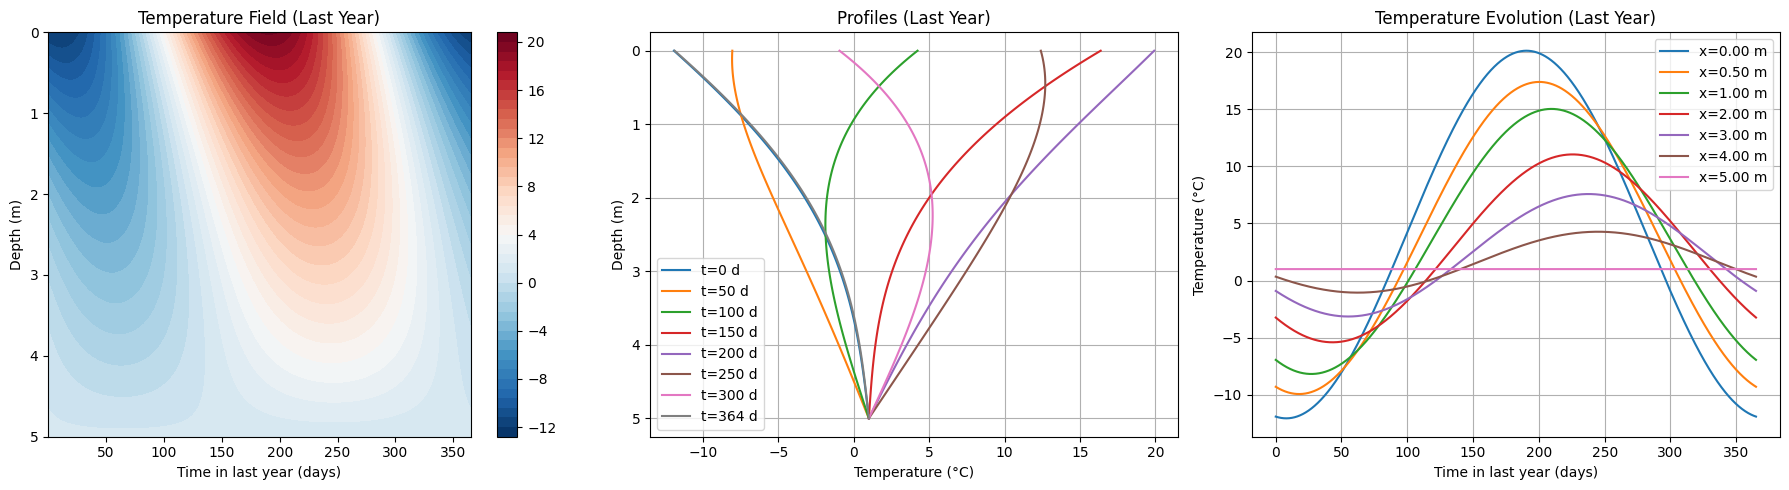

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time


class HeatConduction1D:
    """
    Clean 1D heat conduction model without phase change.
    This is a baseline model used to verify whether the annual thermal wave
    is transmitted correctly into the soil.
    """

    def __init__(self, params):
        self.C = params['C']              # volumetric heat capacity, MJ/(m^3·K)
        self.lmbda = params['lambda']     # thermal conductivity, MJ/(day·m·K)

        self.Nx = None
        self.Nt = None
        self.Lx = None
        self.T_total = None
        self.dx = None
        self.dt = None

        self.x = None
        self.t = None
        self.T_field = None

    # ============================================================
    # Boundary / initial conditions
    # ============================================================
    def boundary_temperature(self, t):
        return 4.03 + 16.11 * np.sin(2.0 * np.pi * t / 365.0 - 1.709)

    def initial_temperature_profile(self, x):
        T_surface = self.boundary_temperature(0.0)
        T_bottom = 1.0
        return T_surface + (T_bottom - T_surface) / 5.0 * x

    # ============================================================
    # Initialization
    # ============================================================
    def initialize(self, Nx=101, Nt=15000, Lx=5.0, T_total=365.0 * 3):
        self.Nx = Nx
        self.Nt = Nt
        self.Lx = Lx
        self.T_total = T_total

        self.dx = Lx / (Nx - 1)
        self.dt = T_total / (Nt - 1)

        self.x = np.linspace(0.0, Lx, Nx)
        self.t = np.linspace(0.0, T_total, Nt)

        self.T_field = np.zeros((Nx, Nt), dtype=float)
        self.T_field[:, 0] = self.initial_temperature_profile(self.x)

    # ============================================================
    # Implicit solver
    # ============================================================
    def solve_implicit(self, verbose=True):
        if self.T_field is None:
            raise RuntimeError("Please call initialize() first.")

        start = time.time()
        T = self.T_field[:, 0].copy()

        alpha = self.lmbda / self.C  # thermal diffusivity

        if verbose:
            print("Starting clean linear heat conduction solver...")
            print(f"alpha = {alpha:.6e} m^2/day")
            print(f"dx = {self.dx:.6f}, dt = {self.dt:.6f}")

        r = alpha * self.dt / self.dx**2

        for n in range(1, self.Nt):
            t_n = self.t[n]

            A = np.zeros((self.Nx, self.Nx), dtype=float)
            b = np.zeros(self.Nx, dtype=float)

            # Boundary conditions
            A[0, 0] = 1.0
            b[0] = self.boundary_temperature(t_n)

            A[-1, -1] = 1.0
            b[-1] = 1.0

            # Interior nodes
            for i in range(1, self.Nx - 1):
                A[i, i - 1] = -r
                A[i, i]     = 1.0 + 2.0 * r
                A[i, i + 1] = -r
                b[i] = T[i]

            T_new = np.linalg.solve(A, b)

            if np.any(np.isnan(T_new)) or np.any(np.isinf(T_new)):
                raise RuntimeError(f"NaN/Inf detected at step {n}")

            self.T_field[:, n] = T_new
            T = T_new.copy()

            if verbose and n % max(1, self.Nt // 10) == 0:
                print(f"  Progress: {100.0 * n / self.Nt:.1f}%   elapsed: {time.time() - start:.1f}s")

        if verbose:
            print(f"Solver completed in {time.time() - start:.1f}s")

        return self.T_field

    # ============================================================
    # Extract last year
    # ============================================================
    def get_last_year_data(self):
        t_start = self.T_total - 365.0
        mask = self.t >= t_start
        t_last = self.t[mask] - t_start
        T_last = self.T_field[:, mask]
        return t_last, T_last

    # ============================================================
    # Save
    # ============================================================
    def save_last_year_results(self, filename='linear_fdm_last_year.npz'):
        t_last, T_last = self.get_last_year_data()
        np.savez(filename, x=self.x, t=t_last, T_field=T_last)
        print(f"Saved last-year results to {filename}")

    # ============================================================
    # Plot last year
    # ============================================================
    def plot_last_year_results(self):
        t_last, T_last = self.get_last_year_data()

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        im = axes[0].contourf(t_last, self.x, T_last, levels=40, cmap='RdBu_r')
        axes[0].invert_yaxis()
        axes[0].set_xlabel('Time in last year (days)')
        axes[0].set_ylabel('Depth (m)')
        axes[0].set_title('Temperature Field (Last Year)')
        plt.colorbar(im, ax=axes[0])

        times_to_plot = [0, 50, 100, 150, 200, 250, 300, 364]
        for tt in times_to_plot:
            idx = np.argmin(np.abs(t_last - tt))
            axes[1].plot(T_last[:, idx], self.x, label=f't={t_last[idx]:.0f} d')
        axes[1].invert_yaxis()
        axes[1].set_xlabel('Temperature (°C)')
        axes[1].set_ylabel('Depth (m)')
        axes[1].set_title('Profiles (Last Year)')
        axes[1].legend()
        axes[1].grid(True)

        depths_to_plot = [0, 0.5, 1, 2, 3, 4, 5]
        for dd in depths_to_plot:
            idx = np.argmin(np.abs(self.x - dd))
            axes[2].plot(t_last, T_last[idx, :], label=f'x={self.x[idx]:.2f} m')
        axes[2].set_xlabel('Time in last year (days)')
        axes[2].set_ylabel('Temperature (°C)')
        axes[2].set_title('Temperature Evolution (Last Year)')
        axes[2].legend()
        axes[2].grid(True)

        plt.tight_layout()
        plt.show()


if __name__ == "__main__":
    # Use representative constant properties
    params = {
        'C': 2.2,         # MJ/(m^3·K)
        'lambda': 0.15    # MJ/(day·m·K)
    }

    model = HeatConduction1D(params)
    model.initialize(Nx=101, Nt=15000, Lx=5.0, T_total=365.0 * 3)
    T_field = model.solve_implicit(verbose=True)
    model.save_last_year_results("linear_fdm_last_year.npz")
    model.plot_last_year_results()

# 2 一个“只加温度相关物性、不加潜热”的完整版本。

Starting implicit solver with variable properties but no latent heat...
Diagnostics:
  T range      : [-11.926392, 1.000000]
  phi range    : [0.075933, 1.000000]
  C_eff range  : [1.704976, 2.632000]
  lambda range : [0.119750, 0.175478]
  dx = 0.050000, dt = 0.073005
  Progress: 10.0%   elapsed: 1.1s
  Progress: 20.0%   elapsed: 2.1s
  Progress: 30.0%   elapsed: 3.2s
  Progress: 40.0%   elapsed: 4.1s
  Progress: 50.0%   elapsed: 5.1s
  Progress: 60.0%   elapsed: 6.1s
  Progress: 70.0%   elapsed: 7.1s
  Progress: 80.0%   elapsed: 8.1s
  Progress: 90.0%   elapsed: 9.0s
Implicit solution completed in 10.0s
Diagnostics:
  T range      : [-11.926392, 1.033622]
  phi range    : [0.075933, 1.000000]
  C_eff range  : [1.704976, 2.632000]
  lambda range : [0.119750, 0.175478]
  dx = 0.050000, dt = 0.073005
Last-year results saved to variable_properties_no_latent_last_year.npz
All-years T min = -12.079999989780223
All-years T max = 20.13999975659201
Surface final T = -11.92639217305949
Bottom 

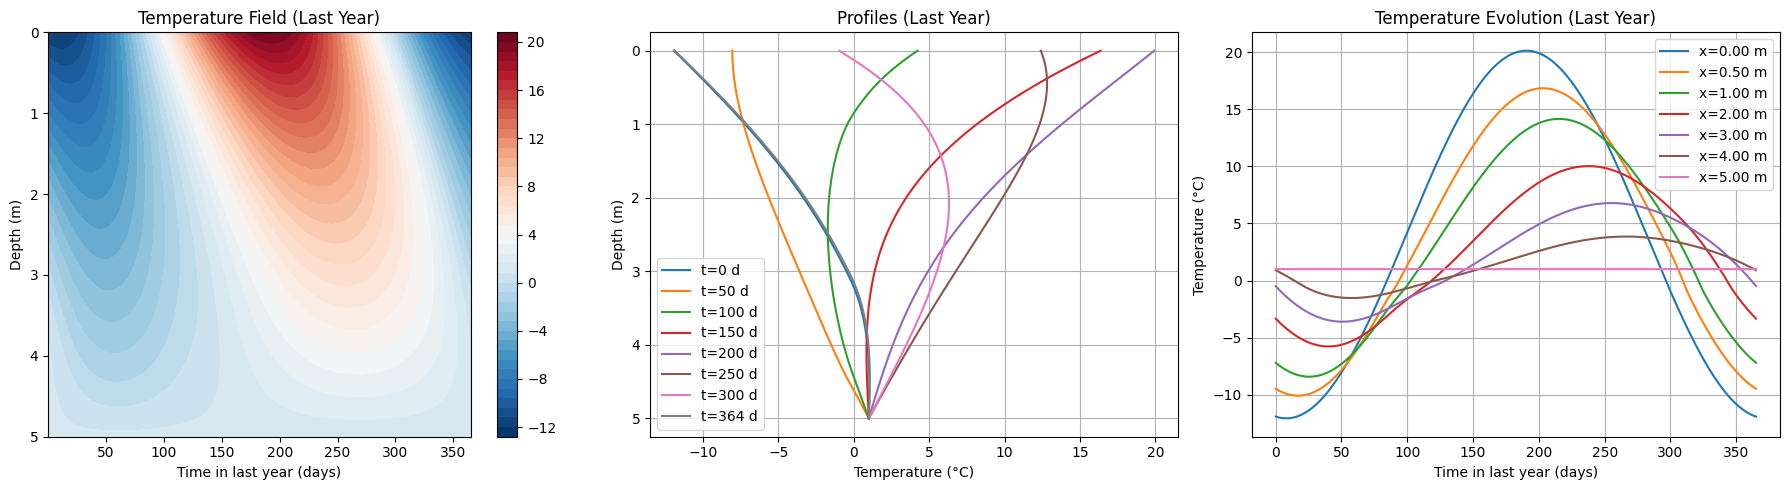

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time


class HeatConduction1DVariableProperties:
    """
    1D heat conduction model with temperature-dependent properties:
        C_eff(T), lambda_eff(T)
    but without latent heat term.

    This model is used to test whether the problem comes from:
    - variable material properties
    or
    - latent heat / phase change treatment
    """

    def __init__(self, params):
        # ---------------- Physical parameters ----------------
        self.C_i = params['C_i']
        self.C_l = params['C_l']
        self.C_f = params['C_f']
        self.lambda_i = params['lambda_i']
        self.lambda_l = params['lambda_l']
        self.lambda_f = params['lambda_f']
        self.eta = params['eta']
        self.b = params['b']
        self.T_nabla = params['T_nabla']

        # ---------------- Smoothing parameters ----------------
        self.k_phi = params.get('k_phi', 1.5)
        self.eps_phi = params.get('eps_phi', 1e-6)

        # ---------------- Grid parameters ----------------
        self.Nx = None
        self.Nt = None
        self.Lx = None
        self.T_total = None
        self.dx = None
        self.dt = None

        self.x = None
        self.t = None
        self.T_field = None

    # ============================================================
    # Boundary / initial conditions
    # ============================================================
    def boundary_temperature(self, t):
        return 4.03 + 16.11 * np.sin(2.0 * np.pi * t / 365.0 - 1.709)

    def initial_temperature_profile(self, x):
        T_surface = self.boundary_temperature(0.0)
        T_bottom = 1.0
        return T_surface + (T_bottom - T_surface) / 5.0 * x

    # ============================================================
    # Stable sigmoid
    # ============================================================
    def stable_sigmoid(self, z):
        z = np.asarray(z, dtype=float)
        z = np.clip(z, -60.0, 60.0)
        return 1.0 / (1.0 + np.exp(-z))

    # ============================================================
    # Constitutive relations
    # ============================================================
    def pore_water_content(self, T):
        """
        Smoothed pore liquid water fraction phi(T), physically constrained to [0, 1].
        """
        T = np.asarray(T, dtype=float)
        T_abs = np.clip(np.abs(T), self.eps_phi, None)

        phi_frozen = (abs(self.T_nabla) ** self.b) * (T_abs ** (-self.b))
        phi_frozen = np.minimum(phi_frozen, 1.0)

        z = self.k_phi * (T - self.T_nabla)
        step = self.stable_sigmoid(z)

        phi = step * 1.0 + (1.0 - step) * phi_frozen
        return np.clip(phi, 0.0, 1.0)

    def effective_heat_capacity(self, T):
        phi = self.pore_water_content(T)
        return (
            (1.0 - self.eta) * self.C_f
            + self.eta * (phi * self.C_l + (1.0 - phi) * self.C_i)
        )

    def effective_conductivity(self, T):
        phi = self.pore_water_content(T)
        return (
            (1.0 - self.eta) * self.lambda_f
            + self.eta * (phi * self.lambda_l + (1.0 - phi) * self.lambda_i)
        )

    @staticmethod
    def harmonic_mean(a, b, eps=1e-12):
        return 2.0 * a * b / (a + b + eps)

    # ============================================================
    # Initialization
    # ============================================================
    def initialize(self, Nx=101, Nt=15000, Lx=5.0, T_total=365.0 * 3):
        self.Nx = Nx
        self.Nt = Nt
        self.Lx = Lx
        self.T_total = T_total

        self.dx = Lx / (Nx - 1)
        self.dt = T_total / (Nt - 1)

        self.x = np.linspace(0.0, Lx, Nx)
        self.t = np.linspace(0.0, T_total, Nt)

        self.T_field = np.zeros((Nx, Nt), dtype=float)
        self.T_field[:, 0] = self.initial_temperature_profile(self.x)

    # ============================================================
    # Diagnostics
    # ============================================================
    def print_diagnostics(self, T):
        phi = self.pore_water_content(T)
        Ceff = self.effective_heat_capacity(T)
        lam = self.effective_conductivity(T)

        print("Diagnostics:")
        print(f"  T range      : [{np.min(T):.6f}, {np.max(T):.6f}]")
        print(f"  phi range    : [{np.min(phi):.6f}, {np.max(phi):.6f}]")
        print(f"  C_eff range  : [{np.min(Ceff):.6f}, {np.max(Ceff):.6f}]")
        print(f"  lambda range : [{np.min(lam):.6f}, {np.max(lam):.6f}]")
        print(f"  dx = {self.dx:.6f}, dt = {self.dt:.6f}")

    # ============================================================
    # Implicit solver
    # ============================================================
    def solve_implicit(self, verbose=True):
        """
        Implicit solver for:
            C_eff(T) * dT/dt = d/dx( lambda_eff(T) * dT/dx )

        Material properties are evaluated at old time step (semi-implicit).
        """
        if self.T_field is None:
            raise RuntimeError("Please call initialize() first.")

        start = time.time()
        T = self.T_field[:, 0].copy()

        if verbose:
            print("Starting implicit solver with variable properties but no latent heat...")
            self.print_diagnostics(T)

        for n in range(1, self.Nt):
            t_n = self.t[n]

            C_eff = self.effective_heat_capacity(T)
            lambda_eff = self.effective_conductivity(T)

            A = np.zeros((self.Nx, self.Nx), dtype=float)
            b = np.zeros(self.Nx, dtype=float)

            # Boundary conditions
            A[0, 0] = 1.0
            b[0] = self.boundary_temperature(t_n)

            A[-1, -1] = 1.0
            b[-1] = 1.0

            # Interior nodes
            for i in range(1, self.Nx - 1):
                lam_p = self.harmonic_mean(lambda_eff[i], lambda_eff[i + 1])
                lam_m = self.harmonic_mean(lambda_eff[i], lambda_eff[i - 1])

                alpha = self.dt / (C_eff[i] * self.dx**2)

                A[i, i - 1] = -0.5 * alpha * lam_m
                A[i, i]     =  1.0 + 0.5 * alpha * (lam_p + lam_m)
                A[i, i + 1] = -0.5 * alpha * lam_p

                conduction = 0.5 * alpha * (
                    lam_p * (T[i + 1] - T[i]) - lam_m * (T[i] - T[i - 1])
                )

                b[i] = T[i] + conduction

            T_new = np.linalg.solve(A, b)

            if np.any(np.isnan(T_new)) or np.any(np.isinf(T_new)):
                raise RuntimeError(f"NaN/Inf detected at time step {n}")

            self.T_field[:, n] = T_new
            T = T_new.copy()

            if verbose and n % max(1, self.Nt // 10) == 0:
                print(f"  Progress: {100.0 * n / self.Nt:.1f}%   elapsed: {time.time() - start:.1f}s")

        if verbose:
            print(f"Implicit solution completed in {time.time() - start:.1f}s")
            self.print_diagnostics(T)

        return self.T_field

    # ============================================================
    # Extract last year
    # ============================================================
    def get_last_year_data(self):
        if self.T_field is None:
            raise RuntimeError("No results available.")

        t_start = self.T_total - 365.0
        mask = self.t >= t_start

        t_last = self.t[mask] - t_start
        T_last = self.T_field[:, mask]

        return t_last, T_last

    # ============================================================
    # Save
    # ============================================================
    def save_last_year_results(self, filename='variable_properties_no_latent_last_year.npz'):
        t_last, T_last = self.get_last_year_data()

        np.savez(
            filename,
            x=self.x,
            t=t_last,
            T_field=T_last,
            params={
                'C_i': self.C_i,
                'C_l': self.C_l,
                'C_f': self.C_f,
                'lambda_i': self.lambda_i,
                'lambda_l': self.lambda_l,
                'lambda_f': self.lambda_f,
                'eta': self.eta,
                'b': self.b,
                'T_nabla': self.T_nabla,
                'k_phi': self.k_phi,
                'eps_phi': self.eps_phi
            }
        )
        print(f"Last-year results saved to {filename}")

    # ============================================================
    # Plot last year
    # ============================================================
    def plot_last_year_results(self):
        t_last, T_last = self.get_last_year_data()

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        im = axes[0].contourf(t_last, self.x, T_last, levels=40, cmap='RdBu_r')
        axes[0].invert_yaxis()
        axes[0].set_xlabel('Time in last year (days)')
        axes[0].set_ylabel('Depth (m)')
        axes[0].set_title('Temperature Field (Last Year)')
        plt.colorbar(im, ax=axes[0])

        times_to_plot = [0, 50, 100, 150, 200, 250, 300, 364]
        for tt in times_to_plot:
            idx = np.argmin(np.abs(t_last - tt))
            axes[1].plot(T_last[:, idx], self.x, label=f't={t_last[idx]:.0f} d')
        axes[1].invert_yaxis()
        axes[1].set_xlabel('Temperature (°C)')
        axes[1].set_ylabel('Depth (m)')
        axes[1].set_title('Profiles (Last Year)')
        axes[1].legend()
        axes[1].grid(True)

        depths_to_plot = [0, 0.5, 1, 2, 3, 4, 5]
        for dd in depths_to_plot:
            idx = np.argmin(np.abs(self.x - dd))
            axes[2].plot(t_last, T_last[idx, :], label=f'x={self.x[idx]:.2f} m')
        axes[2].set_xlabel('Time in last year (days)')
        axes[2].set_ylabel('Temperature (°C)')
        axes[2].set_title('Temperature Evolution (Last Year)')
        axes[2].legend()
        axes[2].grid(True)

        plt.tight_layout()
        plt.show()


if __name__ == "__main__":
    params = {
        'C_i': 1.672,
        'C_l': 4.18,
        'C_f': 1.6,
        'lambda_i': 2.210e-6 * 8.64e4,
        'lambda_l': 0.465e-6 * 8.64e4,
        'lambda_f': 2e-6 * 8.64e4,
        'eta': 0.4,
        'b': 0.7,
        'T_nabla': -0.3,
        'k_phi': 1.5,
        'eps_phi': 1e-6
    }

    model = HeatConduction1DVariableProperties(params)

    # 3-year spin-up
    model.initialize(Nx=101, Nt=15000, Lx=5.0, T_total=365.0 * 3)

    T_field = model.solve_implicit(verbose=True)

    model.save_last_year_results("variable_properties_no_latent_last_year.npz")

    print("All-years T min =", np.min(T_field))
    print("All-years T max =", np.max(T_field))
    print("Surface final T =", T_field[0, -1])
    print("Bottom final T =", T_field[-1, -1])

    model.plot_last_year_results()

# 3 基于“变量物性但无潜热”的正确版本，只重写潜热项。

Starting implicit FDM solver with apparent heat capacity...
Diagnostics:
  T range        : [-11.926392, 1.000000]
  phi range      : [0.075941, 1.000000]
  dphi/dT range  : [-0.578998, 0.746085]
  dtheta/dT range: [-0.231599, 0.298434]
  C_eff range    : [1.704984, 2.632000]
  C_app range    : [0.001000, 79.948792]
  lambda range   : [0.119750, 0.175478]
  dx = 0.050000, dt = 0.073005
  Progress: 10.0%   elapsed: 1.1s
  Progress: 20.0%   elapsed: 2.2s
  Progress: 30.0%   elapsed: 3.4s
  Progress: 40.0%   elapsed: 4.4s
  Progress: 50.0%   elapsed: 5.5s
  Progress: 60.0%   elapsed: 6.5s
  Progress: 70.0%   elapsed: 7.7s
  Progress: 80.0%   elapsed: 8.8s
  Progress: 90.0%   elapsed: 9.9s
Implicit solution completed in 11.0s
Diagnostics:
  T range        : [-11.926392, 1.000000]
  phi range      : [0.075941, 1.000000]
  dphi/dT range  : [-0.667820, 0.764071]
  dtheta/dT range: [-0.267128, 0.305628]
  C_eff range    : [1.704984, 2.632000]
  C_app range    : [0.001000, 91.829183]
  lambda r

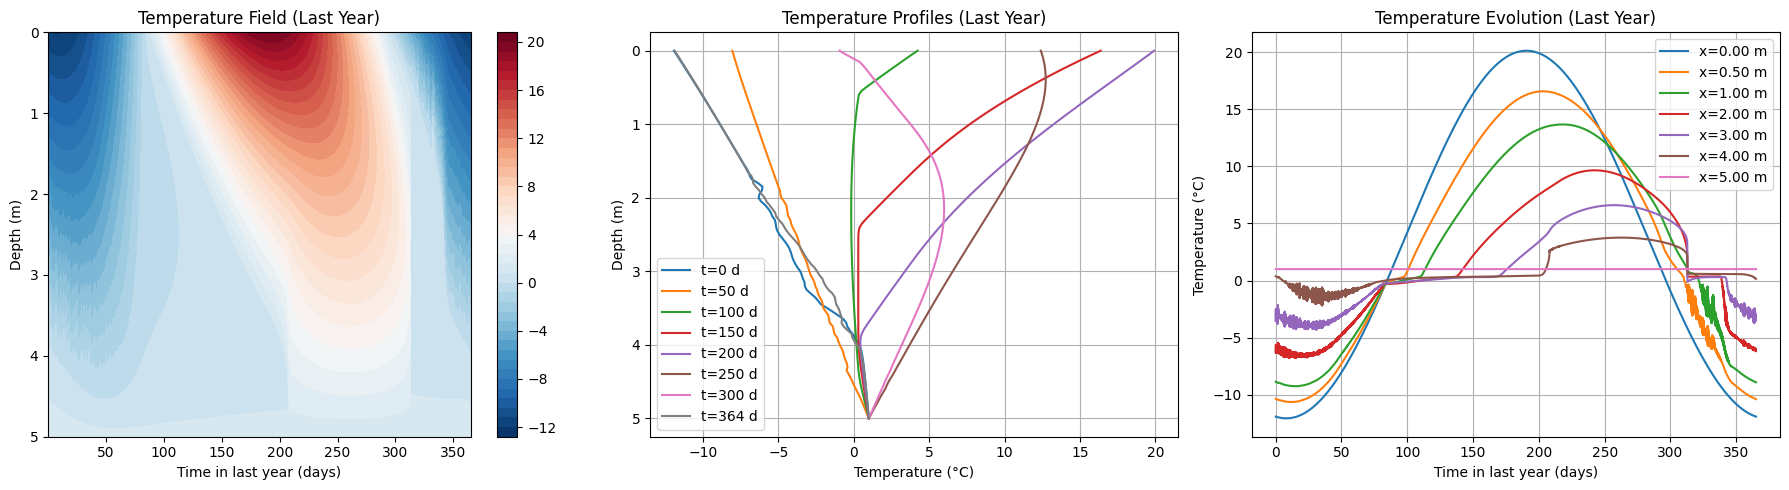

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import time


class FreezingSoilFDM:
    """
    1D finite difference model for freezing/thawing soil.
    Latent heat is handled by the apparent heat capacity method:
        C_app(T) = C_eff(T) - L * dtheta/dT
    """

    def __init__(self, params):
        # ---------------- Physical parameters ----------------
        self.L = params['L']                    # latent heat (MJ/m^3)
        self.C_i = params['C_i']
        self.C_l = params['C_l']
        self.C_f = params['C_f']
        self.lambda_i = params['lambda_i']
        self.lambda_l = params['lambda_l']
        self.lambda_f = params['lambda_f']
        self.eta = params['eta']
        self.b = params['b']
        self.T_nabla = params['T_nabla']

        # ---------------- Smoothing parameters ----------------
        self.k_phi = params.get('k_phi', 1.5)
        self.eps_phi = params.get('eps_phi', 1e-6)

        # safety floor for apparent heat capacity
        self.Capp_min = params.get('Capp_min', 1e-6)

        # ---------------- Grid parameters ----------------
        self.Nx = None
        self.Nt = None
        self.Lx = None
        self.T_total = None
        self.dx = None
        self.dt = None

        self.x = None
        self.t = None
        self.T_field = None

    # ============================================================
    # Boundary / initial conditions
    # ============================================================
    def boundary_temperature(self, t):
        return 4.03 + 16.11 * np.sin(2.0 * np.pi * t / 365.0 - 1.709)

    def initial_temperature_profile(self, x):
        T_surface = self.boundary_temperature(0.0)
        T_bottom = 1.0
        return T_surface + (T_bottom - T_surface) / 5.0 * x

    # ============================================================
    # Stable sigmoid and derivative
    # ============================================================
    def stable_sigmoid(self, z):
        z = np.asarray(z, dtype=float)
        z = np.clip(z, -60.0, 60.0)
        return 1.0 / (1.0 + np.exp(-z))

    def stable_sigmoid_derivative(self, z):
        s = self.stable_sigmoid(z)
        return s * (1.0 - s)

    # ============================================================
    # Constitutive relations
    # ============================================================
    def pore_water_content(self, T):
        """
        Smoothed phi(T), physically constrained to [0, 1].
        """
        T = np.asarray(T, dtype=float)
        T_abs = np.clip(np.abs(T), self.eps_phi, None)

        phi_frozen = (abs(self.T_nabla) ** self.b) * (T_abs ** (-self.b))
        phi_frozen = np.minimum(phi_frozen, 1.0)

        z = self.k_phi * (T - self.T_nabla)
        step = self.stable_sigmoid(z)

        phi = step * 1.0 + (1.0 - step) * phi_frozen
        return np.clip(phi, 0.0, 1.0)

    def dphi_dT(self, T):
        """
        Analytical derivative of phi(T) with respect to T.

        phi(T) = step(T)*1 + (1-step(T))*phi_frozen(T)
              = phi_frozen + step*(1-phi_frozen)
        """
        T = np.asarray(T, dtype=float)

        T_abs = np.clip(np.abs(T), self.eps_phi, None)

        # phi_frozen = |T_nabla|^b * |T|^{-b}
        A = abs(self.T_nabla) ** self.b
        phi_frozen = A * (T_abs ** (-self.b))
        phi_frozen = np.minimum(phi_frozen, 1.0)

        # derivative of phi_frozen before the cap
        dphi_frozen_raw = -A * self.b * np.sign(T) * (T_abs ** (-self.b - 1.0))

        # if phi_frozen is capped at 1, derivative should be zero there
        mask_capped = (A * (T_abs ** (-self.b))) >= 1.0
        dphi_frozen = np.where(mask_capped, 0.0, dphi_frozen_raw)

        z = self.k_phi * (T - self.T_nabla)
        step = self.stable_sigmoid(z)
        dstep_dT = self.k_phi * self.stable_sigmoid_derivative(z)

        # phi = phi_frozen + step * (1 - phi_frozen)
        # dphi/dT = dphi_frozen + dstep*(1-phi_frozen) - step*dphi_frozen
        #         = (1-step)*dphi_frozen + dstep*(1-phi_frozen)
        dphi = (1.0 - step) * dphi_frozen + dstep_dT * (1.0 - phi_frozen)

        return dphi

    def unfrozen_water_content(self, T):
        return self.eta * self.pore_water_content(T)

    def dtheta_dT(self, T):
        return self.eta * self.dphi_dT(T)

    def effective_heat_capacity(self, T):
        phi = self.pore_water_content(T)
        return (
            (1.0 - self.eta) * self.C_f
            + self.eta * (phi * self.C_l + (1.0 - phi) * self.C_i)
        )

    def apparent_heat_capacity(self, T):
        """
        C_app = C_eff - L * dtheta/dT

        Since dtheta/dT is usually negative in the freezing interval,
        -L*dtheta/dT becomes positive and increases the effective storage.
        """
        C_eff = self.effective_heat_capacity(T)
        dtheta = self.dtheta_dT(T)
        C_app = C_eff - self.L * dtheta

        # numerical safety floor
        return np.maximum(C_app, self.Capp_min)

    def effective_conductivity(self, T):
        phi = self.pore_water_content(T)
        return (
            (1.0 - self.eta) * self.lambda_f
            + self.eta * (phi * self.lambda_l + (1.0 - phi) * self.lambda_i)
        )

    @staticmethod
    def harmonic_mean(a, b, eps=1e-12):
        return 2.0 * a * b / (a + b + eps)

    # ============================================================
    # Initialization
    # ============================================================
    def initialize(self, Nx=101, Nt=15000, Lx=5.0, T_total=365.0 * 3):
        self.Nx = Nx
        self.Nt = Nt
        self.Lx = Lx
        self.T_total = T_total

        self.dx = Lx / (Nx - 1)
        self.dt = T_total / (Nt - 1)

        self.x = np.linspace(0.0, Lx, Nx)
        self.t = np.linspace(0.0, T_total, Nt)

        T_init = self.initial_temperature_profile(self.x)

        self.T_field = np.zeros((Nx, Nt), dtype=float)
        self.T_field[:, 0] = T_init

    # ============================================================
    # Diagnostics
    # ============================================================
    def print_diagnostics(self, T):
        phi = self.pore_water_content(T)
        dphi = self.dphi_dT(T)
        dtheta = self.dtheta_dT(T)
        Ceff = self.effective_heat_capacity(T)
        Capp = self.apparent_heat_capacity(T)
        lam = self.effective_conductivity(T)

        print("Diagnostics:")
        print(f"  T range        : [{np.min(T):.6f}, {np.max(T):.6f}]")
        print(f"  phi range      : [{np.min(phi):.6f}, {np.max(phi):.6f}]")
        print(f"  dphi/dT range  : [{np.min(dphi):.6f}, {np.max(dphi):.6f}]")
        print(f"  dtheta/dT range: [{np.min(dtheta):.6f}, {np.max(dtheta):.6f}]")
        print(f"  C_eff range    : [{np.min(Ceff):.6f}, {np.max(Ceff):.6f}]")
        print(f"  C_app range    : [{np.min(Capp):.6f}, {np.max(Capp):.6f}]")
        print(f"  lambda range   : [{np.min(lam):.6f}, {np.max(lam):.6f}]")
        print(f"  dx = {self.dx:.6f}, dt = {self.dt:.6f}")

    # ============================================================
    # Implicit solver with apparent heat capacity
    # ============================================================
    def solve_implicit(self, verbose=True):
        """
        Implicit FDM with latent heat handled by apparent heat capacity:
            C_app(T) * dT/dt = d/dx ( lambda(T) dT/dx )
        """
        if self.T_field is None:
            raise RuntimeError("Please call initialize() first.")

        start = time.time()
        T = self.T_field[:, 0].copy()

        if verbose:
            print("Starting implicit FDM solver with apparent heat capacity...")
            self.print_diagnostics(T)

        for n in range(1, self.Nt):
            t_n = self.t[n]

            # evaluate coefficients using previous time step temperature
            C_app = self.apparent_heat_capacity(T)
            lambda_eff = self.effective_conductivity(T)

            A = np.zeros((self.Nx, self.Nx), dtype=float)
            b = np.zeros(self.Nx, dtype=float)

            # boundary conditions
            A[0, 0] = 1.0
            b[0] = self.boundary_temperature(t_n)

            A[-1, -1] = 1.0
            b[-1] = 1.0

            for i in range(1, self.Nx - 1):
                lam_p = self.harmonic_mean(lambda_eff[i], lambda_eff[i + 1])
                lam_m = self.harmonic_mean(lambda_eff[i], lambda_eff[i - 1])

                alpha = self.dt / (C_app[i] * self.dx**2)

                # Crank-Nicolson type form
                A[i, i - 1] = -0.5 * alpha * lam_m
                A[i, i] = 1.0 + 0.5 * alpha * (lam_p + lam_m)
                A[i, i + 1] = -0.5 * alpha * lam_p

                conduction = 0.5 * alpha * (
                    lam_p * (T[i + 1] - T[i]) - lam_m * (T[i] - T[i - 1])
                )

                b[i] = T[i] + conduction

            T_new = np.linalg.solve(A, b)

            if np.any(np.isnan(T_new)) or np.any(np.isinf(T_new)):
                raise RuntimeError(f"NaN/Inf detected at time step {n}")

            self.T_field[:, n] = T_new
            T = T_new.copy()

            if verbose and n % max(1, self.Nt // 10) == 0:
                print(f"  Progress: {100.0 * n / self.Nt:.1f}%   elapsed: {time.time() - start:.1f}s")

        if verbose:
            print(f"Implicit solution completed in {time.time() - start:.1f}s")
            self.print_diagnostics(T)

        return self.T_field

    # ============================================================
    # Save all years
    # ============================================================
    def save_results(self, filename='fdm_results_3years.npz'):
        np.savez(
            filename,
            x=self.x,
            t=self.t,
            T_field=self.T_field,
            params={
                'L': self.L,
                'C_i': self.C_i,
                'C_l': self.C_l,
                'C_f': self.C_f,
                'lambda_i': self.lambda_i,
                'lambda_l': self.lambda_l,
                'lambda_f': self.lambda_f,
                'eta': self.eta,
                'b': self.b,
                'T_nabla': self.T_nabla,
                'k_phi': self.k_phi,
                'eps_phi': self.eps_phi,
                'Capp_min': self.Capp_min
            }
        )
        print(f"Results saved to {filename}")

    # ============================================================
    # Extract last year
    # ============================================================
    def get_last_year_data(self):
        if self.T_field is None:
            raise RuntimeError("No results available.")

        t_start = self.T_total - 365.0
        mask = self.t >= t_start

        t_last = self.t[mask] - t_start
        T_last = self.T_field[:, mask]

        return t_last, T_last

    # ============================================================
    # Save only last year
    # ============================================================
    def save_last_year_results(self, filename='fdm_results_last_year.npz'):
        t_last, T_last = self.get_last_year_data()

        np.savez(
            filename,
            x=self.x,
            t=t_last,
            T_field=T_last,
            params={
                'L': self.L,
                'C_i': self.C_i,
                'C_l': self.C_l,
                'C_f': self.C_f,
                'lambda_i': self.lambda_i,
                'lambda_l': self.lambda_l,
                'lambda_f': self.lambda_f,
                'eta': self.eta,
                'b': self.b,
                'T_nabla': self.T_nabla,
                'k_phi': self.k_phi,
                'eps_phi': self.eps_phi,
                'Capp_min': self.Capp_min
            }
        )
        print(f"Last-year results saved to {filename}")

    # ============================================================
    # Plot all years
    # ============================================================
    def plot_results(self):
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        im = axes[0].contourf(self.t, self.x, self.T_field, levels=40, cmap='RdBu_r')
        axes[0].invert_yaxis()
        axes[0].set_xlabel('Time (days)')
        axes[0].set_ylabel('Depth (m)')
        axes[0].set_title('Temperature Field (All Years)')
        plt.colorbar(im, ax=axes[0])

        times_to_plot = [0, 100, 365, 730, 900, 1094]
        for tt in times_to_plot:
            idx = np.argmin(np.abs(self.t - tt))
            axes[1].plot(self.T_field[:, idx], self.x, label=f't={self.t[idx]:.0f} d')
        axes[1].invert_yaxis()
        axes[1].set_xlabel('Temperature (°C)')
        axes[1].set_ylabel('Depth (m)')
        axes[1].set_title('Temperature Profiles (All Years)')
        axes[1].legend()
        axes[1].grid(True)

        depths_to_plot = [0, 0.5, 1, 2, 3, 4, 5]
        for dd in depths_to_plot:
            idx = np.argmin(np.abs(self.x - dd))
            axes[2].plot(self.t, self.T_field[idx, :], label=f'x={self.x[idx]:.2f} m')
        axes[2].set_xlabel('Time (days)')
        axes[2].set_ylabel('Temperature (°C)')
        axes[2].set_title('Temperature Evolution (All Years)')
        axes[2].legend()
        axes[2].grid(True)

        plt.tight_layout()
        plt.show()

    # ============================================================
    # Plot only last year
    # ============================================================
    def plot_last_year_results(self):
        t_last, T_last = self.get_last_year_data()

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        im = axes[0].contourf(t_last, self.x, T_last, levels=40, cmap='RdBu_r')
        axes[0].invert_yaxis()
        axes[0].set_xlabel('Time in last year (days)')
        axes[0].set_ylabel('Depth (m)')
        axes[0].set_title('Temperature Field (Last Year)')
        plt.colorbar(im, ax=axes[0])

        times_to_plot = [0, 50, 100, 150, 200, 250, 300, 364]
        for tt in times_to_plot:
            idx = np.argmin(np.abs(t_last - tt))
            axes[1].plot(T_last[:, idx], self.x, label=f't={t_last[idx]:.0f} d')
        axes[1].invert_yaxis()
        axes[1].set_xlabel('Temperature (°C)')
        axes[1].set_ylabel('Depth (m)')
        axes[1].set_title('Temperature Profiles (Last Year)')
        axes[1].legend()
        axes[1].grid(True)

        depths_to_plot = [0, 0.5, 1, 2, 3, 4, 5]
        for dd in depths_to_plot:
            idx = np.argmin(np.abs(self.x - dd))
            axes[2].plot(t_last, T_last[idx, :], label=f'x={self.x[idx]:.2f} m')
        axes[2].set_xlabel('Time in last year (days)')
        axes[2].set_ylabel('Temperature (°C)')
        axes[2].set_title('Temperature Evolution (Last Year)')
        axes[2].legend()
        axes[2].grid(True)

        plt.tight_layout()
        plt.show()


if __name__ == "__main__":
    params = {
        'L': 334,
        'C_i': 1.672,
        'C_l': 4.18,
        'lambda_i': 2.210e-6 * 8.64e4,
        'lambda_l': 0.465e-6 * 8.64e4,
        'lambda_f': 2e-6 * 8.64e4,
        'C_f': 1.6,
        'eta': 0.4,
        'b': 0.7,
        'T_nabla': -0.3,
        'k_phi': 1.0,
        'eps_phi': 1e-4,
        'Capp_min': 1e-3
    }

    model = FreezingSoilFDM(params)

    model.initialize(Nx=101, Nt=15000, Lx=5.0, T_total=365.0 * 3)

    T_field = model.solve_implicit(verbose=True)

    model.save_results("fdm_results_3years.npz")
    model.save_last_year_results("fdm_results_last_year.npz")

    print("All-years T min =", np.min(T_field))
    print("All-years T max =", np.max(T_field))
    print("Surface final T =", T_field[0, -1])
    print("Bottom final T =", T_field[-1, -1])

    model.plot_last_year_results()

# Phase change

In [4]:
pip install scipy

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
Note: you may need to restart the kernel to use updated packages.


Starting clean implicit FDM solver with 3-year spin-up...
Diagnostics:
  T range      : [-11.926392, 1.000000]
  phi range    : [0.075933, 1.000000]
  C_eff range  : [1.704976, 2.632000]
  lambda range : [0.119750, 0.175478]
  dx = 0.050000, dt = 0.073005
  Progress: 10.0%   elapsed: 1.1s
  Progress: 20.0%   elapsed: 2.3s
  Progress: 30.0%   elapsed: 3.4s
  Progress: 40.0%   elapsed: 4.6s
  Progress: 50.0%   elapsed: 5.7s
  Progress: 60.0%   elapsed: 6.8s
  Progress: 70.0%   elapsed: 7.9s
  Progress: 80.0%   elapsed: 9.1s
  Progress: 90.0%   elapsed: 10.2s
Implicit solution completed in 11.4s
Diagnostics:
  T range      : [-11.926392, 1.995993]
  phi range    : [0.075933, 1.000000]
  C_eff range  : [1.704976, 2.632000]
  lambda range : [0.119750, 0.175478]
  dx = 0.050000, dt = 0.073005
Results saved to fdm_results_3years.npz
Last-year results saved to fdm_results_last_year.npz
All-years T min = -12.079999989780216
All-years T max = 20.13999975659201
Surface final T = -11.9263921730594

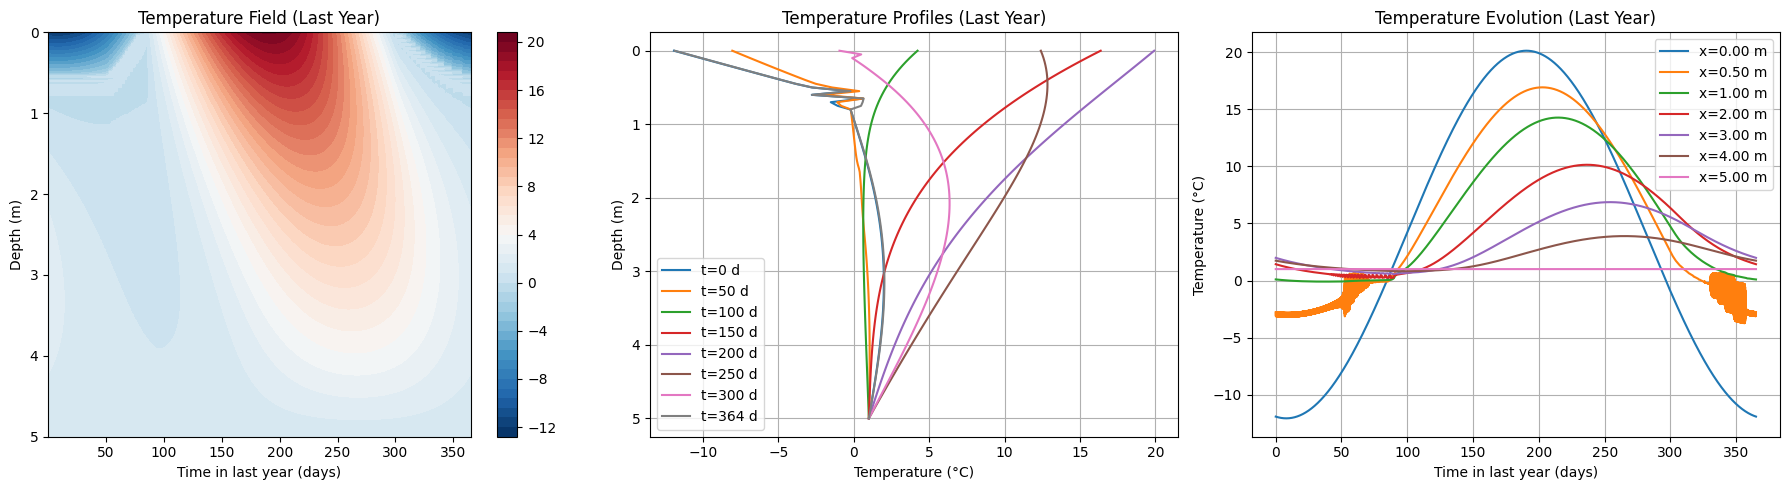

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import time


class FreezingSoilFDM:
    """
    Clean 1D finite difference model for freezing/thawing soil.
    This version uses multi-year spin-up and analyzes only the last year.
    """

    def __init__(self, params):
        # ---------------- Physical parameters ----------------
        self.L = params['L']                    # latent heat (MJ/m^3)
        self.C_i = params['C_i']
        self.C_l = params['C_l']
        self.C_f = params['C_f']
        self.lambda_i = params['lambda_i']
        self.lambda_l = params['lambda_l']
        self.lambda_f = params['lambda_f']
        self.eta = params['eta']
        self.b = params['b']
        self.T_nabla = params['T_nabla']

        # ---------------- Smoothing parameters ----------------
        self.k_phi = params.get('k_phi', 1.5)
        self.eps_phi = params.get('eps_phi', 1e-6)

        # ---------------- Grid parameters ----------------
        self.Nx = None
        self.Nt = None
        self.Lx = None
        self.T_total = None
        self.dx = None
        self.dt = None

        self.x = None
        self.t = None
        self.T_field = None
        self.theta_old = None

    # ============================================================
    # Boundary / initial conditions
    # ============================================================
    def boundary_temperature(self, t):
        return 4.03 + 16.11 * np.sin(2.0 * np.pi * t / 365.0 - 1.709)

    def initial_temperature_profile(self, x):
        T_surface = self.boundary_temperature(0.0)
        T_bottom = 1.0
        return T_surface + (T_bottom - T_surface) / 5.0 * x

    # ============================================================
    # Stable sigmoid
    # ============================================================
    def stable_sigmoid(self, z):
        z = np.asarray(z, dtype=float)
        z = np.clip(z, -60.0, 60.0)
        return 1.0 / (1.0 + np.exp(-z))

    # ============================================================
    # Constitutive relations
    # ============================================================
    def pore_water_content(self, T):
        """
        Smoothed phi(T), physically constrained to [0, 1].
        """
        T = np.asarray(T, dtype=float)
        T_abs = np.clip(np.abs(T), self.eps_phi, None)

        phi_frozen = (abs(self.T_nabla) ** self.b) * (T_abs ** (-self.b))
        phi_frozen = np.minimum(phi_frozen, 1.0)

        z = self.k_phi * (T - self.T_nabla)
        step = self.stable_sigmoid(z)

        phi = step * 1.0 + (1.0 - step) * phi_frozen
        return np.clip(phi, 0.0, 1.0)

    def unfrozen_water_content(self, T):
        return self.eta * self.pore_water_content(T)

    def effective_heat_capacity(self, T):
        phi = self.pore_water_content(T)
        return (
            (1.0 - self.eta) * self.C_f
            + self.eta * (phi * self.C_l + (1.0 - phi) * self.C_i)
        )

    def effective_conductivity(self, T):
        phi = self.pore_water_content(T)
        return (
            (1.0 - self.eta) * self.lambda_f
            + self.eta * (phi * self.lambda_l + (1.0 - phi) * self.lambda_i)
        )

    @staticmethod
    def harmonic_mean(a, b, eps=1e-12):
        return 2.0 * a * b / (a + b + eps)

    # ============================================================
    # Initialization
    # ============================================================
    def initialize(self, Nx=101, Nt=15000, Lx=5.0, T_total=365.0 * 3):
        """
        Default setup: 3 years total simulation
        """
        self.Nx = Nx
        self.Nt = Nt
        self.Lx = Lx
        self.T_total = T_total

        self.dx = Lx / (Nx - 1)
        self.dt = T_total / (Nt - 1)

        self.x = np.linspace(0.0, Lx, Nx)
        self.t = np.linspace(0.0, T_total, Nt)

        T_init = self.initial_temperature_profile(self.x)

        self.T_field = np.zeros((Nx, Nt), dtype=float)
        self.T_field[:, 0] = T_init
        self.theta_old = self.unfrozen_water_content(T_init)

    # ============================================================
    # Diagnostics
    # ============================================================
    def print_diagnostics(self, T):
        phi = self.pore_water_content(T)
        Ceff = self.effective_heat_capacity(T)
        lam = self.effective_conductivity(T)

        print("Diagnostics:")
        print(f"  T range      : [{np.min(T):.6f}, {np.max(T):.6f}]")
        print(f"  phi range    : [{np.min(phi):.6f}, {np.max(phi):.6f}]")
        print(f"  C_eff range  : [{np.min(Ceff):.6f}, {np.max(Ceff):.6f}]")
        print(f"  lambda range : [{np.min(lam):.6f}, {np.max(lam):.6f}]")
        print(f"  dx = {self.dx:.6f}, dt = {self.dt:.6f}")

    # ============================================================
    # Implicit solver
    # ============================================================
    def solve_implicit(self, verbose=True):
        """
        Clean implicit FDM with latent heat handled by:
            dtheta/dt ≈ (theta_cur - theta_old) / dt
        """
        if self.T_field is None:
            raise RuntimeError("Please call initialize() first.")

        start = time.time()
        T = self.T_field[:, 0].copy()

        if verbose:
            print("Starting clean implicit FDM solver with 3-year spin-up...")
            self.print_diagnostics(T)

        for n in range(1, self.Nt):
            t_n = self.t[n]

            theta_cur = self.unfrozen_water_content(T)
            C_eff = self.effective_heat_capacity(T)
            lambda_eff = self.effective_conductivity(T)

            A = np.zeros((self.Nx, self.Nx), dtype=float)
            b = np.zeros(self.Nx, dtype=float)

            # boundary conditions
            A[0, 0] = 1.0
            b[0] = self.boundary_temperature(t_n)

            A[-1, -1] = 1.0
            b[-1] = 1.0

            for i in range(1, self.Nx - 1):
                lam_p = self.harmonic_mean(lambda_eff[i], lambda_eff[i + 1])
                lam_m = self.harmonic_mean(lambda_eff[i], lambda_eff[i - 1])

                alpha = self.dt / (C_eff[i] * self.dx**2)

                A[i, i - 1] = -0.5 * alpha * lam_m
                A[i, i] = 1.0 + 0.5 * alpha * (lam_p + lam_m)
                A[i, i + 1] = -0.5 * alpha * lam_p

                conduction = 0.5 * alpha * (
                    lam_p * (T[i + 1] - T[i]) - lam_m * (T[i] - T[i - 1])
                )

                latent = self.L * (theta_cur[i] - self.theta_old[i]) / C_eff[i]

                b[i] = T[i] + conduction - self.dt * latent

            T_new = np.linalg.solve(A, b)

            if np.any(np.isnan(T_new)) or np.any(np.isinf(T_new)):
                raise RuntimeError(f"NaN/Inf detected at time step {n}")

            self.T_field[:, n] = T_new
            T = T_new.copy()
            self.theta_old = theta_cur.copy()

            if verbose and n % max(1, self.Nt // 10) == 0:
                print(f"  Progress: {100.0 * n / self.Nt:.1f}%   elapsed: {time.time() - start:.1f}s")

        if verbose:
            print(f"Implicit solution completed in {time.time() - start:.1f}s")
            self.print_diagnostics(T)

        return self.T_field

    # ============================================================
    # Save all years
    # ============================================================
    def save_results(self, filename='fdm_results_3years.npz'):
        np.savez(
            filename,
            x=self.x,
            t=self.t,
            T_field=self.T_field,
            params={
                'L': self.L,
                'C_i': self.C_i,
                'C_l': self.C_l,
                'C_f': self.C_f,
                'lambda_i': self.lambda_i,
                'lambda_l': self.lambda_l,
                'lambda_f': self.lambda_f,
                'eta': self.eta,
                'b': self.b,
                'T_nabla': self.T_nabla,
                'k_phi': self.k_phi,
                'eps_phi': self.eps_phi
            }
        )
        print(f"Results saved to {filename}")

    # ============================================================
    # Extract last year
    # ============================================================
    def get_last_year_data(self):
        if self.T_field is None:
            raise RuntimeError("No results available.")

        t_start = self.T_total - 365.0
        mask = self.t >= t_start

        t_last = self.t[mask] - t_start
        T_last = self.T_field[:, mask]

        return t_last, T_last

    # ============================================================
    # Save only last year
    # ============================================================
    def save_last_year_results(self, filename='fdm_results_last_year.npz'):
        t_last, T_last = self.get_last_year_data()

        np.savez(
            filename,
            x=self.x,
            t=t_last,
            T_field=T_last,
            params={
                'L': self.L,
                'C_i': self.C_i,
                'C_l': self.C_l,
                'C_f': self.C_f,
                'lambda_i': self.lambda_i,
                'lambda_l': self.lambda_l,
                'lambda_f': self.lambda_f,
                'eta': self.eta,
                'b': self.b,
                'T_nabla': self.T_nabla,
                'k_phi': self.k_phi,
                'eps_phi': self.eps_phi
            }
        )
        print(f"Last-year results saved to {filename}")

    # ============================================================
    # Plot all years
    # ============================================================
    def plot_results(self):
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        im = axes[0].contourf(self.t, self.x, self.T_field, levels=40, cmap='RdBu_r')
        axes[0].invert_yaxis()
        axes[0].set_xlabel('Time (days)')
        axes[0].set_ylabel('Depth (m)')
        axes[0].set_title('Temperature Field (All Years)')
        plt.colorbar(im, ax=axes[0])

        times_to_plot = [0, 100, 365, 730, 900, 1094]
        for tt in times_to_plot:
            idx = np.argmin(np.abs(self.t - tt))
            axes[1].plot(self.T_field[:, idx], self.x, label=f't={self.t[idx]:.0f} d')
        axes[1].invert_yaxis()
        axes[1].set_xlabel('Temperature (°C)')
        axes[1].set_ylabel('Depth (m)')
        axes[1].set_title('Temperature Profiles (All Years)')
        axes[1].legend()
        axes[1].grid(True)

        depths_to_plot = [0, 0.5, 1, 2, 3, 4, 5]
        for dd in depths_to_plot:
            idx = np.argmin(np.abs(self.x - dd))
            axes[2].plot(self.t, self.T_field[idx, :], label=f'x={self.x[idx]:.2f} m')
        axes[2].set_xlabel('Time (days)')
        axes[2].set_ylabel('Temperature (°C)')
        axes[2].set_title('Temperature Evolution (All Years)')
        axes[2].legend()
        axes[2].grid(True)

        plt.tight_layout()
        plt.show()

    # ============================================================
    # Plot only last year
    # ============================================================
    def plot_last_year_results(self):
        t_last, T_last = self.get_last_year_data()

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        im = axes[0].contourf(t_last, self.x, T_last, levels=40, cmap='RdBu_r')
        axes[0].invert_yaxis()
        axes[0].set_xlabel('Time in last year (days)')
        axes[0].set_ylabel('Depth (m)')
        axes[0].set_title('Temperature Field (Last Year)')
        plt.colorbar(im, ax=axes[0])

        times_to_plot = [0, 50, 100, 150, 200, 250, 300, 364]
        for tt in times_to_plot:
            idx = np.argmin(np.abs(t_last - tt))
            axes[1].plot(T_last[:, idx], self.x, label=f't={t_last[idx]:.0f} d')
        axes[1].invert_yaxis()
        axes[1].set_xlabel('Temperature (°C)')
        axes[1].set_ylabel('Depth (m)')
        axes[1].set_title('Temperature Profiles (Last Year)')
        axes[1].legend()
        axes[1].grid(True)

        depths_to_plot = [0, 0.5, 1, 2, 3, 4, 5]
        for dd in depths_to_plot:
            idx = np.argmin(np.abs(self.x - dd))
            axes[2].plot(t_last, T_last[idx, :], label=f'x={self.x[idx]:.2f} m')
        axes[2].set_xlabel('Time in last year (days)')
        axes[2].set_ylabel('Temperature (°C)')
        axes[2].set_title('Temperature Evolution (Last Year)')
        axes[2].legend()
        axes[2].grid(True)

        plt.tight_layout()
        plt.show()


if __name__ == "__main__":
    params = {
        'L': 334,
        'C_i': 1.672,
        'C_l': 4.18,
        'lambda_i': 2.210e-6 * 8.64e4,
        'lambda_l': 0.465e-6 * 8.64e4,
        'lambda_f': 2e-6 * 8.64e4,
        'C_f': 1.6,
        'eta': 0.4,
        'b': 0.7,
        'T_nabla': -0.3,
        'k_phi': 1.5,
        'eps_phi': 1e-6
    }

    model = FreezingSoilFDM(params)

    # 3-year spin-up
    model.initialize(Nx=101, Nt=15000, Lx=5.0, T_total=365.0 * 3)

    T_field = model.solve_implicit(verbose=True)

    # Save all 3 years
    model.save_results("fdm_results_3years.npz")

    # Save only the last year
    model.save_last_year_results("fdm_results_last_year.npz")

    print("All-years T min =", np.min(T_field))
    print("All-years T max =", np.max(T_field))
    print("Surface final T =", T_field[0, -1])
    print("Bottom final T =", T_field[-1, -1])

    # Plot only the last year for analysis
    model.plot_last_year_results()

# 5年的结果 近似apparent capacity methods


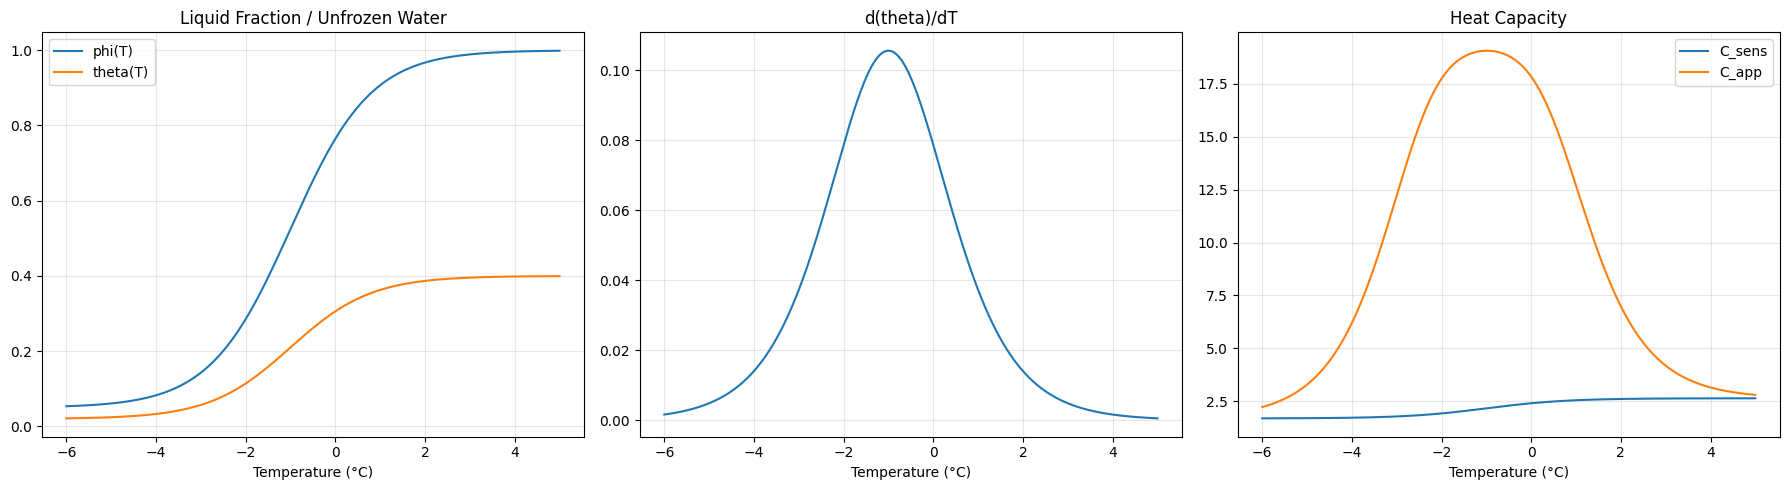

Starting apparent heat capacity solver (improved smooth version)...
Diagnostics:
  T range         : [-11.926392, 1.000000]
  phi range       : [0.050005, 0.907116]
  theta range     : [0.020002, 0.362846]
  dtheta/dT range : [2.254303e-06, 1.054343e-01]
  C_sens range    : [1.678965, 2.538819]
  C_app range     : [1.678965, 19.070674]
  lambda range    : [0.125352, 0.177042]
  dx = 0.050000, dt = 0.030417
  Progress: 10.0%   elapsed: 45.5s
  Progress: 20.0%   elapsed: 90.6s
  Progress: 30.0%   elapsed: 138.0s
  Progress: 40.0%   elapsed: 188.8s
  Progress: 50.0%   elapsed: 248.9s
  Progress: 60.0%   elapsed: 295.1s
  Progress: 70.0%   elapsed: 343.5s
  Progress: 80.0%   elapsed: 392.7s
  Progress: 90.0%   elapsed: 461.9s
Solver completed in 511.5s
Diagnostics:
  T range         : [-11.926390, 2.240353]
  phi range       : [0.050005, 0.974743]
  theta range     : [0.020002, 0.389897]
  dtheta/dT range : [2.254307e-06, 1.053018e-01]
  C_sens range    : [1.678965, 2.606662]
  C_app range

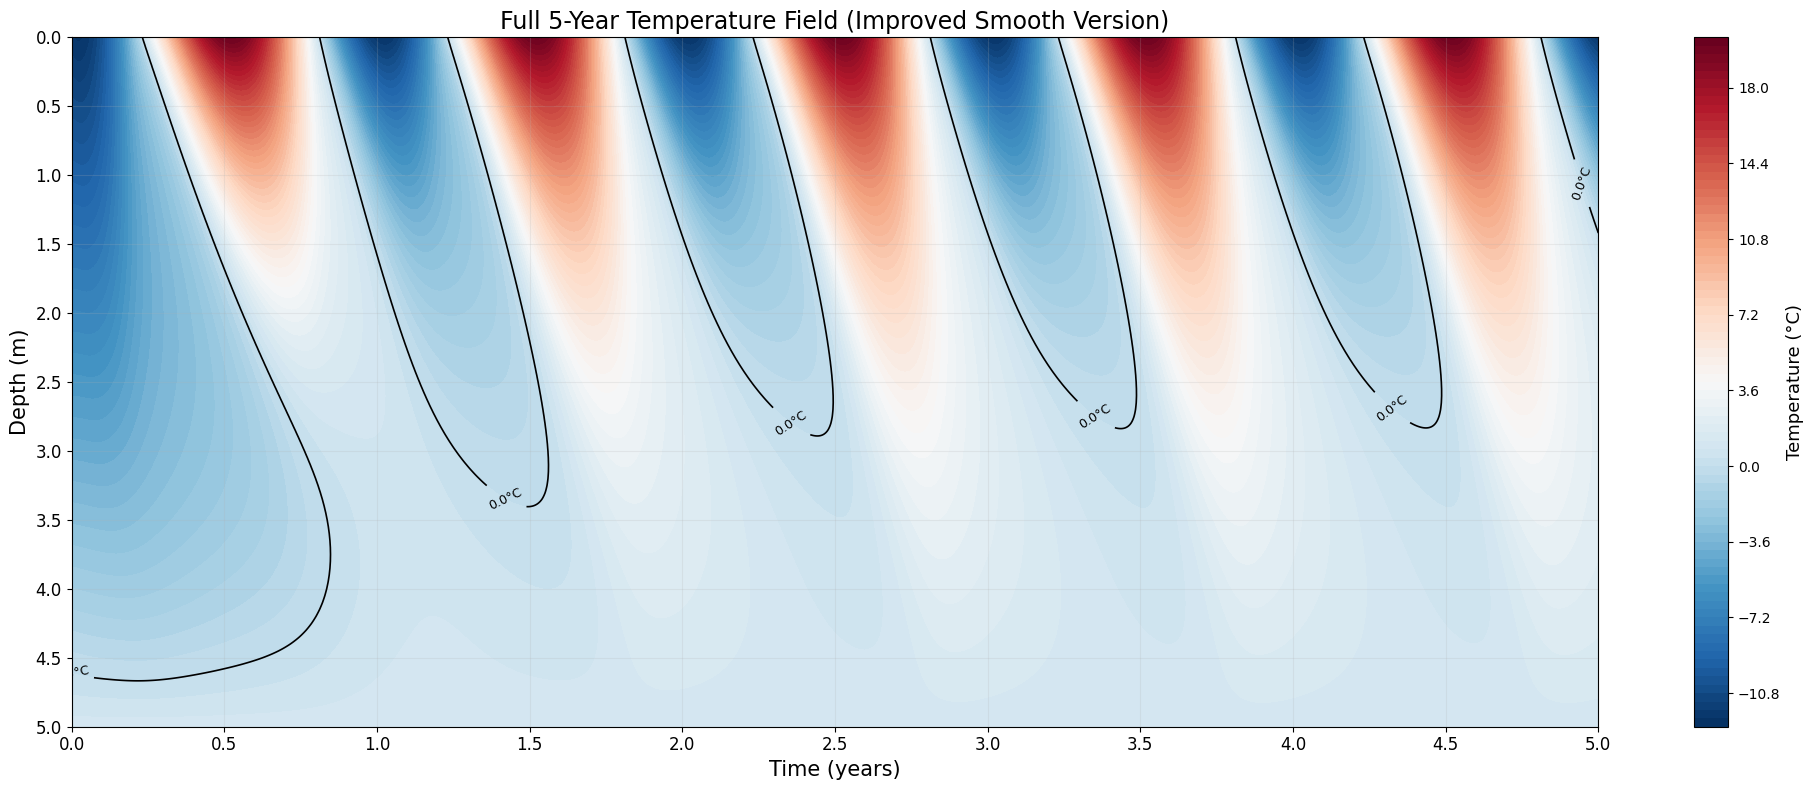

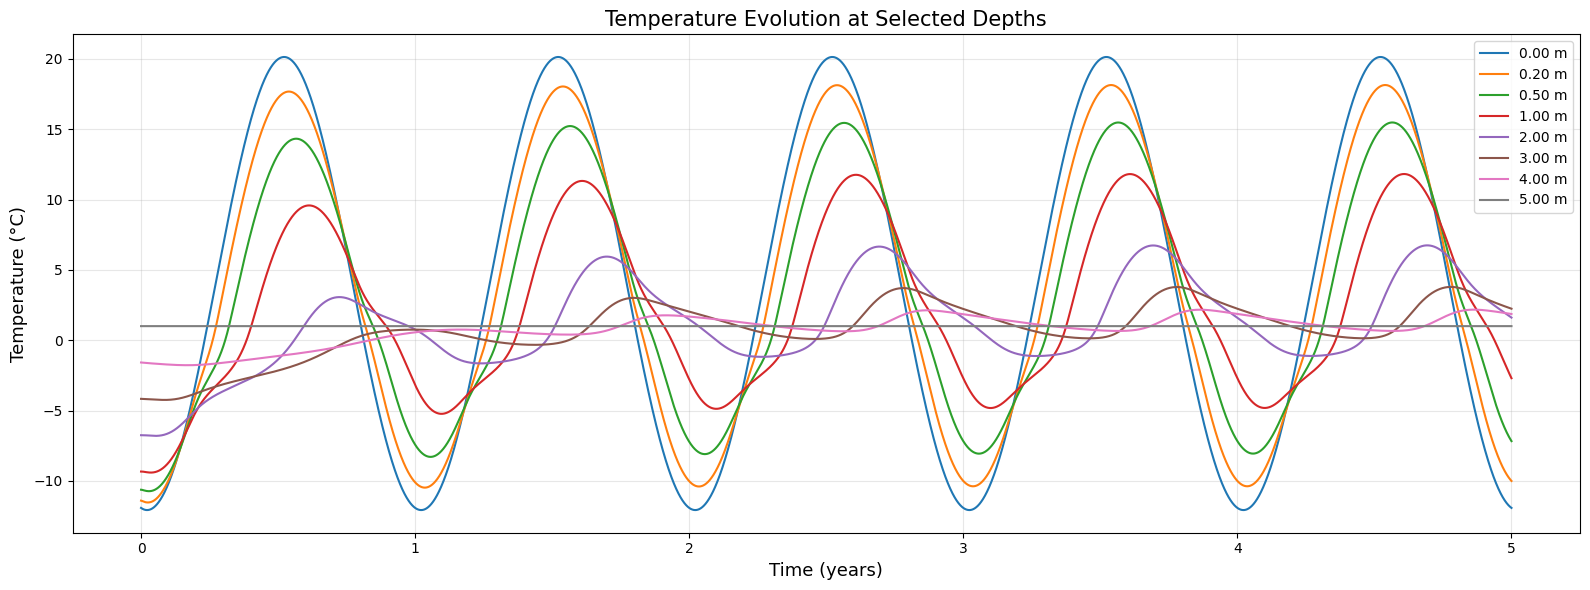

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import time


class FreezingSoilFDM:
    """
    1D finite difference model for soil freezing/thawing
    using the apparent heat capacity method.

    Governing equation:
        C_app(T) * dT/dt = d/dx( lambda(T) * dT/dx )

    Main improvements:
    1. tanh-based smooth unfrozen water curve
    2. smooth saturation of apparent heat capacity
    3. nonlinear iteration with convergence check
    4. under-relaxation for better continuity near 0°C
    """

    def __init__(self, params):
        # ---------------- Physical parameters ----------------
        self.L = params['L']                    # latent heat (MJ/m^3)
        self.C_i = params['C_i']                # volumetric heat capacity of ice
        self.C_l = params['C_l']                # volumetric heat capacity of liquid water
        self.C_f = params['C_f']                # volumetric heat capacity of soil skeleton

        self.lambda_i = params['lambda_i']      # thermal conductivity of ice
        self.lambda_l = params['lambda_l']      # thermal conductivity of liquid water
        self.lambda_f = params['lambda_f']      # thermal conductivity of soil skeleton

        self.eta = params['eta']                # porosity

        # ---------------- Smooth freezing curve parameters ----------------
        self.phi_res = params.get('phi_res', 0.05)
        self.T_transition_mid = params.get('T_transition_mid', -1.0)
        self.T_transition_width = params.get('T_transition_width', 1.8)

        # ---------------- Numerical stabilization ----------------
        self.C_app_max = params.get('C_app_max', 20.0)
        self.relax_default = params.get('relax_default', 0.35)

        # ---------------- Grid parameters ----------------
        self.Nx = None
        self.Nt = None
        self.Lx = None
        self.T_total = None
        self.dx = None
        self.dt = None

        self.x = None
        self.t = None
        self.T_field = None

    # ============================================================
    # Boundary and initial conditions
    # ============================================================
    def boundary_temperature(self, t):
        """
        Surface boundary temperature as a sinusoidal function.
        t in days
        """
        return 4.03 + 16.11 * np.sin(2.0 * np.pi * t / 365.0 - 1.709)

    def initial_temperature_profile(self, x):
        """
        Linear initial temperature profile.
        """
        T_surface = self.boundary_temperature(0.0)
        T_bottom = 1.0
        return T_surface + (T_bottom - T_surface) / 5.0 * x

    # ============================================================
    # Utility
    # ============================================================
    @staticmethod
    def harmonic_mean(a, b, eps=1e-12):
        return 2.0 * a * b / (a + b + eps)

    # ============================================================
    # Smooth tanh-based freezing characteristic functions
    # ============================================================
    def pore_water_content(self, T):
        """
        Smooth unfrozen water fraction using a tanh-type transition.
        """
        T = np.asarray(T, dtype=float)

        phi_res = self.phi_res
        T_mid = self.T_transition_mid
        dT = self.T_transition_width

        z = (T - T_mid) / dT
        z = np.clip(z, -50.0, 50.0)

        phi = phi_res + (1.0 - phi_res) * 0.5 * (1.0 + np.tanh(z))
        return np.clip(phi, phi_res, 1.0)

    def dphi_dT(self, T):
        """
        Analytical derivative of tanh-based unfrozen water curve.
        """
        T = np.asarray(T, dtype=float)

        phi_res = self.phi_res
        T_mid = self.T_transition_mid
        dT = self.T_transition_width

        z = (T - T_mid) / dT
        z = np.clip(z, -50.0, 50.0)

        sech2 = 1.0 / np.cosh(z) ** 2
        dphi = (1.0 - phi_res) * 0.5 * sech2 / dT

        return dphi

    def unfrozen_water_content(self, T):
        """
        Volumetric unfrozen water content theta(T)
        """
        return self.eta * self.pore_water_content(T)

    def dtheta_dT(self, T):
        """
        d(theta)/dT
        """
        return self.eta * self.dphi_dT(T)

    # ============================================================
    # Effective properties
    # ============================================================
    def sensible_heat_capacity(self, T):
        """
        Sensible volumetric heat capacity
        """
        phi = self.pore_water_content(T)
        return (
            (1.0 - self.eta) * self.C_f
            + self.eta * (phi * self.C_l + (1.0 - phi) * self.C_i)
        )

    def apparent_heat_capacity(self, T):
        """
        Apparent heat capacity with smooth saturation instead of hard clipping.
        This avoids artificial kinks near the phase-change zone.
        """
        C_sens = self.sensible_heat_capacity(T)
        dtheta = self.dtheta_dT(T)

        C_raw = C_sens + self.L * np.abs(dtheta)
        C_raw = np.maximum(C_raw, 1e-8)

        Cmax = self.C_app_max

        # smooth saturation
        C_app = Cmax * np.tanh(C_raw / Cmax)

        # ensure not lower than sensible heat capacity
        return np.maximum(C_app, C_sens)

    def effective_conductivity(self, T):
        """
        Effective conductivity based on liquid fraction.
        """
        phi = self.pore_water_content(T)
        return (
            (1.0 - self.eta) * self.lambda_f
            + self.eta * (phi * self.lambda_l + (1.0 - phi) * self.lambda_i)
        )

    # ============================================================
    # Initialization
    # ============================================================
    def initialize(self, Nx=101, Nt=60000, Lx=5.0, T_total=365.0 * 5):
        """
        Default setup: 5 years with finer time resolution.
        """
        self.Nx = Nx
        self.Nt = Nt
        self.Lx = Lx
        self.T_total = T_total

        self.dx = Lx / (Nx - 1)
        self.dt = T_total / (Nt - 1)

        self.x = np.linspace(0.0, Lx, Nx)
        self.t = np.linspace(0.0, T_total, Nt)

        T_init = self.initial_temperature_profile(self.x)

        self.T_field = np.zeros((Nx, Nt), dtype=float)
        self.T_field[:, 0] = T_init

    # ============================================================
    # Diagnostics
    # ============================================================
    def print_diagnostics(self, T):
        phi = self.pore_water_content(T)
        theta = self.unfrozen_water_content(T)
        dtheta = self.dtheta_dT(T)
        C_sens = self.sensible_heat_capacity(T)
        C_app = self.apparent_heat_capacity(T)
        lam = self.effective_conductivity(T)

        print("Diagnostics:")
        print(f"  T range         : [{np.min(T):.6f}, {np.max(T):.6f}]")
        print(f"  phi range       : [{np.min(phi):.6f}, {np.max(phi):.6f}]")
        print(f"  theta range     : [{np.min(theta):.6f}, {np.max(theta):.6f}]")
        print(f"  dtheta/dT range : [{np.min(dtheta):.6e}, {np.max(dtheta):.6e}]")
        print(f"  C_sens range    : [{np.min(C_sens):.6f}, {np.max(C_sens):.6f}]")
        print(f"  C_app range     : [{np.min(C_app):.6f}, {np.max(C_app):.6f}]")
        print(f"  lambda range    : [{np.min(lam):.6f}, {np.max(lam):.6f}]")
        print(f"  dx = {self.dx:.6f}, dt = {self.dt:.6f}")

    # ============================================================
    # Solver
    # ============================================================
    def solve_implicit(self, verbose=True, nonlinear_iter=15, relax=None, tol=1e-6):
        """
        Semi-implicit Picard-style solver with under-relaxation
        and convergence check.
        """
        if self.T_field is None:
            raise RuntimeError("Please call initialize() first.")

        if relax is None:
            relax = self.relax_default

        start = time.time()
        T_old = self.T_field[:, 0].copy()

        if verbose:
            print("Starting apparent heat capacity solver (improved smooth version)...")
            self.print_diagnostics(T_old)

        for n in range(1, self.Nt):
            t_n = self.t[n]
            T_guess = T_old.copy()
            T_new = T_old.copy()

            for _ in range(nonlinear_iter):
                C_app = self.apparent_heat_capacity(T_guess)
                lambda_eff = self.effective_conductivity(T_guess)

                A = np.zeros((self.Nx, self.Nx), dtype=float)
                b = np.zeros(self.Nx, dtype=float)

                # Top boundary
                A[0, 0] = 1.0
                b[0] = self.boundary_temperature(t_n)

                # Bottom boundary
                A[-1, -1] = 1.0
                b[-1] = 1.0

                for i in range(1, self.Nx - 1):
                    lam_p = self.harmonic_mean(lambda_eff[i], lambda_eff[i + 1])
                    lam_m = self.harmonic_mean(lambda_eff[i], lambda_eff[i - 1])

                    coef = self.dt / (C_app[i] * self.dx**2)

                    A[i, i - 1] = -coef * lam_m
                    A[i, i] = 1.0 + coef * (lam_p + lam_m)
                    A[i, i + 1] = -coef * lam_p

                    b[i] = T_old[i]

                T_solved = np.linalg.solve(A, b)

                # Under-relaxation
                T_new = relax * T_solved + (1.0 - relax) * T_guess

                err = np.max(np.abs(T_new - T_guess))
                T_guess = T_new.copy()

                if err < tol:
                    break

            if np.any(np.isnan(T_new)) or np.any(np.isinf(T_new)):
                raise RuntimeError(f"NaN/Inf detected at time step {n}")

            self.T_field[:, n] = T_new
            T_old = T_new.copy()

            if verbose and n % max(1, self.Nt // 10) == 0:
                print(f"  Progress: {100.0 * n / self.Nt:.1f}%   elapsed: {time.time() - start:.1f}s")

        if verbose:
            print(f"Solver completed in {time.time() - start:.1f}s")
            self.print_diagnostics(T_old)

        return self.T_field

    # ============================================================
    # Save and extract
    # ============================================================
    def save_results(self, filename='fdm_results_5years_improved_smooth.npz'):
        np.savez(
            filename,
            x=self.x,
            t=self.t,
            T_field=self.T_field,
            params={
                'L': self.L,
                'C_i': self.C_i,
                'C_l': self.C_l,
                'C_f': self.C_f,
                'lambda_i': self.lambda_i,
                'lambda_l': self.lambda_l,
                'lambda_f': self.lambda_f,
                'eta': self.eta,
                'phi_res': self.phi_res,
                'T_transition_mid': self.T_transition_mid,
                'T_transition_width': self.T_transition_width,
                'C_app_max': self.C_app_max,
                'relax_default': self.relax_default
            }
        )
        print(f"Results saved to {filename}")

    def get_last_year_data(self):
        if self.T_field is None:
            raise RuntimeError("No results available.")

        t_start = self.T_total - 365.0
        mask = self.t >= t_start

        t_last = self.t[mask] - t_start
        T_last = self.T_field[:, mask]

        return t_last, T_last

    # ============================================================
    # Plots
    # ============================================================
    def plot_full_5years_big(self):
        """
        Plot one large figure of the full 5-year temperature field.
        """
        if self.T_field is None:
            raise RuntimeError("No results available. Please run solve_implicit() first.")

        plt.figure(figsize=(20, 8))

        t_years = self.t / 365.0

        cf = plt.contourf(
            t_years,
            self.x,
            self.T_field,
            levels=80,
            cmap='RdBu_r'
        )

        cs = plt.contour(
            t_years,
            self.x,
            self.T_field,
            levels=[0.0],
            colors='k',
            linewidths=1.2
        )
        plt.clabel(cs, fmt='%1.1f°C', fontsize=9)

        plt.gca().invert_yaxis()

        cbar = plt.colorbar(cf)
        cbar.set_label('Temperature (°C)', fontsize=13)

        plt.xlabel('Time (years)', fontsize=15)
        plt.ylabel('Depth (m)', fontsize=15)
        plt.title('Full 5-Year Temperature Field (Improved Smooth Version)', fontsize=17)

        plt.xticks(np.arange(0, self.T_total / 365.0 + 0.01, 0.5), fontsize=12)
        plt.yticks(np.arange(0, self.Lx + 0.5, 0.5), fontsize=12)
        plt.grid(alpha=0.2)
        plt.tight_layout()
        plt.show()

    def plot_selected_depths(self, depths=None):
        """
        Plot temperature time histories at selected depths.
        """
        if self.T_field is None:
            raise RuntimeError("No results available. Please run solve_implicit() first.")

        if depths is None:
            depths = [0.0, 0.2, 0.5, 1.0, 2.0, 3.0, 4.0, 5.0]

        plt.figure(figsize=(16, 6))

        for d in depths:
            idx = np.argmin(np.abs(self.x - d))
            plt.plot(self.t / 365.0, self.T_field[idx, :], label=f'{self.x[idx]:.2f} m')

        plt.xlabel('Time (years)', fontsize=13)
        plt.ylabel('Temperature (°C)', fontsize=13)
        plt.title('Temperature Evolution at Selected Depths', fontsize=15)
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

    def plot_last_year(self):
        """
        Plot last-year temperature field and selected profiles.
        """
        t_last, T_last = self.get_last_year_data()

        fig, axes = plt.subplots(1, 3, figsize=(20, 5))

        im = axes[0].contourf(t_last, self.x, T_last, levels=60, cmap='RdBu_r')
        axes[0].invert_yaxis()
        axes[0].set_xlabel('Time in last year (days)')
        axes[0].set_ylabel('Depth (m)')
        axes[0].set_title('Temperature Field (Last Year)')
        plt.colorbar(im, ax=axes[0])

        times_to_plot = [0, 50, 100, 150, 200, 250, 300, 364]
        for tt in times_to_plot:
            idx = np.argmin(np.abs(t_last - tt))
            axes[1].plot(T_last[:, idx], self.x, label=f't={t_last[idx]:.0f} d')
        axes[1].invert_yaxis()
        axes[1].set_xlabel('Temperature (°C)')
        axes[1].set_ylabel('Depth (m)')
        axes[1].set_title('Temperature Profiles (Last Year)')
        axes[1].legend()
        axes[1].grid(True)

        depths_to_plot = [0.0, 0.2, 0.5, 1.0, 2.0, 3.0, 4.0, 5.0]
        for d in depths_to_plot:
            idx = np.argmin(np.abs(self.x - d))
            axes[2].plot(t_last, T_last[idx, :], label=f'{self.x[idx]:.2f} m')
        axes[2].set_xlabel('Time in last year (days)')
        axes[2].set_ylabel('Temperature (°C)')
        axes[2].set_title('Temperature Evolution (Last Year)')
        axes[2].legend()
        axes[2].grid(True)

        plt.tight_layout()
        plt.show()

    def plot_material_functions(self, Tmin=-6.0, Tmax=5.0, N=2000):
        """
        Plot phi(T), theta(T), dtheta/dT, C_sens(T), C_app(T).
        Useful for checking whether the freezing transition is smooth enough.
        """
        T = np.linspace(Tmin, Tmax, N)
        phi = self.pore_water_content(T)
        theta = self.unfrozen_water_content(T)
        dtheta = self.dtheta_dT(T)
        C_sens = self.sensible_heat_capacity(T)
        C_app = self.apparent_heat_capacity(T)

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        axes[0].plot(T, phi, label='phi(T)')
        axes[0].plot(T, theta, label='theta(T)')
        axes[0].set_xlabel('Temperature (°C)')
        axes[0].set_title('Liquid Fraction / Unfrozen Water')
        axes[0].grid(True, alpha=0.3)
        axes[0].legend()

        axes[1].plot(T, dtheta)
        axes[1].set_xlabel('Temperature (°C)')
        axes[1].set_title('d(theta)/dT')
        axes[1].grid(True, alpha=0.3)

        axes[2].plot(T, C_sens, label='C_sens')
        axes[2].plot(T, C_app, label='C_app')
        axes[2].set_xlabel('Temperature (°C)')
        axes[2].set_title('Heat Capacity')
        axes[2].grid(True, alpha=0.3)
        axes[2].legend()

        plt.tight_layout()
        plt.show()


if __name__ == "__main__":
    params = {
        # ---------------- Physical parameters ----------------
        'L': 334,                         # MJ/m^3
        'C_i': 1.672,
        'C_l': 4.18,
        'C_f': 1.6,
        'lambda_i': 2.210e-6 * 8.64e4,
        'lambda_l': 0.465e-6 * 8.64e4,
        'lambda_f': 2.0e-6 * 8.64e4,
        'eta': 0.4,

        # ---------------- Smooth freezing curve ----------------
        'phi_res': 0.05,
        'T_transition_mid': -1.0,
        'T_transition_width': 1.8,

        # ---------------- Numerical stabilization ----------------
        'C_app_max': 20.0,
        'relax_default': 0.35
    }

    model = FreezingSoilFDM(params)

    # 5-year simulation
    model.initialize(
        Nx=101,
        Nt=60000,
        Lx=5.0,
        T_total=365.0 * 5
    )

    # Check material functions first
    model.plot_material_functions(Tmin=-6, Tmax=5, N=1500)

    # Solve
    T_field = model.solve_implicit(
        verbose=True,
        nonlinear_iter=15,
        relax=0.35,
        tol=1e-6
    )

    # Save
    model.save_results("fdm_results_5years_improved_smooth.npz")

    print("All-years T min =", np.min(T_field))
    print("All-years T max =", np.max(T_field))
    print("Surface final T =", T_field[0, -1])
    print("Bottom final T =", T_field[-1, -1])

    # Plot
    model.plot_full_5years_big()
    model.plot_selected_depths()

    # Optional:
    # model.plot_last_year()